In [1]:
# Imports et fonctions utiles
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import keras
from keras import layers
from pathlib import Path
from keras import layers

MODEL_FOLDER ="models_projet"
Path(MODEL_FOLDER).mkdir(parents=True, exist_ok=True)

def show_data_img(X, n=200, shape=(28,28), dpi=100):
    plt.figure(figsize=(7.195, 3.841), dpi=dpi)
    nl = n // 20
    if n%20!=0: nl += 1
    
    for i in range(n):
        plt.subplot(nl,20,i+1)
        plt.imshow(X[i,:].reshape(shape), cmap='gray')
        plt.axis('off')
    plt.plot()
    
def show_errors_img(X, Y_pred, Y_true, shape=(28,28), dpi=100):  
    plt.figure(figsize=(7.195, 3.841), dpi=dpi)
    n = min(len(X), len(Y_pred), len(Y_true), 30) # 30 erreurs au maximum
    X, Y_pred, Y_true = X[:n], Y_pred[:n], Y_true[:n]
    nl = n // 10
    if n%10!=0: nl += 1 
    
    for i in range(n):
        plt.subplot(nl,10,i+1)
        x, yp, yt = X[i], Y_pred[i], Y_true[i]
        plt.imshow(x.reshape(shape), cmap='gray')
        plt.axis('off')
        plt.title(str(yp)+' ('+str(yt)+')')
    plt.plot()
    
def show_model_errors(model, X, y):
    proba = model.predict(X)
    y_pred = proba.argmax(axis=1)

    errors = [i for i in range(len(y_pred)) if y_pred[i]!=y[i]]
    show_errors_img(X[errors], y_pred[errors], y[errors])

In [2]:
# Chargement des données winequality
winequality = pd.read_csv('winequality-white.csv', sep=';')

In [4]:
# Décrire les données
print(winequality.head())
print(winequality.info())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.0              0.27         0.36            20.7      0.045   
1            6.3              0.30         0.34             1.6      0.049   
2            8.1              0.28         0.40             6.9      0.050   
3            7.2              0.23         0.32             8.5      0.058   
4            7.2              0.23         0.32             8.5      0.058   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 45.0                 170.0   1.0010  3.00       0.45   
1                 14.0                 132.0   0.9940  3.30       0.49   
2                 30.0                  97.0   0.9951  3.26       0.44   
3                 47.0                 186.0   0.9956  3.19       0.40   
4                 47.0                 186.0   0.9956  3.19       0.40   

   alcohol  quality  
0      8.8        6  
1      9.5        6  
2     10.1        6 

In [5]:
# Tailles des ensembles de données
print("Taille de l'ensemble de données :", winequality.shape)

Taille de l'ensemble de données : (4898, 12)


In [ ]:
# Quelle forme ont les entrées ? Quelles caractéristiques possèdent chaque donnée d'entrée ?
print("Caractéristiques des données d'entrée :", winequality.columns[:-1].tolist())
print(winequality.describe())

Caractéristiques des données d'entrée : ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']
       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    4898.000000       4898.000000  4898.000000     4898.000000   
mean        6.854788          0.278241     0.334192        6.391415   
std         0.843868          0.100795     0.121020        5.072058   
min         3.800000          0.080000     0.000000        0.600000   
25%         6.300000          0.210000     0.270000        1.700000   
50%         6.800000          0.260000     0.320000        5.200000   
75%         7.300000          0.320000     0.390000        9.900000   
max        14.200000          1.100000     1.660000       65.800000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  4898.000000          4898.000000           4898.000000  4898.00

In [ ]:
# Quelle forme ont les sorties ? Quelle est le sens de ces données ?
print("Caractéristiques des données de sortie :", winequality.columns[-1])
print("Valeurs de la qualité du vin :", winequality['quality'].value_counts())
# C'est la qualité du vin, évaluée sur une échelle de 0 à 10 en valeur entière, où 0 est la pire qualité et 10 la meilleure. 
# Dans ce jeu de donnée on constate que les valeurs de qualité varient de 3 à 9. 

Caractéristiques des données de sortie : quality
Valeurs de la qualité du vin : quality
6    2198
5    1457
7     880
8     175
4     163
3      20
9       5
Name: count, dtype: int64


### Commenter brièvement le type de problème à résoudre avec ces données et la difficulté de ce problème

Le but de l'exercice est de prédire la qualité du vins selon la valeurs des 11 colonnes d'entrées.

## 2. Préparation des données 
### Séparer les données en deux ensembles : entraînement et test 

In [ ]:
# Préparation des données en train et en val (80% train, 20% val)
# On dit que pour les 11 colonnes d'entrées il y a 1 réponse de sortie à savoir la qualité du vin.
from sklearn.model_selection import train_test_split
X = winequality.drop('quality', axis=1).values
y = winequality['quality'].values
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
print(X_train[:20])
print(y_train[:20])

[[7.30000000e+00 1.70000000e-01 3.60000000e-01 8.20000000e+00
  2.80000000e-02 4.40000000e+01 1.11000000e+02 9.92720000e-01
  3.14000000e+00 4.10000000e-01 1.24000000e+01]
 [6.30000000e+00 2.50000000e-01 4.40000000e-01 1.16000000e+01
  4.10000000e-02 4.80000000e+01 1.95000000e+02 9.96800000e-01
  3.18000000e+00 5.20000000e-01 9.50000000e+00]
 [5.60000000e+00 3.20000000e-01 3.30000000e-01 7.40000000e+00
  3.70000000e-02 2.50000000e+01 9.50000000e+01 9.92680000e-01
  3.25000000e+00 4.90000000e-01 1.11000000e+01]
 [6.90000000e+00 1.90000000e-01 3.50000000e-01 1.70000000e+00
  3.60000000e-02 3.30000000e+01 1.01000000e+02 9.93150000e-01
  3.21000000e+00 5.40000000e-01 1.08000000e+01]
 [7.70000000e+00 3.00000000e-01 2.60000000e-01 1.89500000e+01
  5.30000000e-02 3.60000000e+01 1.74000000e+02 9.99760000e-01
  3.20000000e+00 5.00000000e-01 1.04000000e+01]
 [6.50000000e+00 4.60000000e-01 2.40000000e-01 1.15000000e+01
  5.10000000e-02 5.60000000e+01 1.71000000e+02 9.95880000e-01
  3.08000000e+00

### Normaliser les données d'entrées


In [13]:
# On normalise les données sans librairie
X_train = (X_train - X_train.min(axis=0)) / (X_train.max(axis=0) - X_train.min(axis=0))
X_val = (X_val - X_val.min(axis=0)) / (X_val.max(axis=0) - X_val.min(axis=0))

## 3. Construction d'un modèle baseline 
Préparation d'un modèle MLP qui servira de base de référence pour comparer les modèles. 

In [30]:
# Pour stocker nos résultats des différents modèles
acc = {}
loss = {}

In [31]:
def baseline():
    m = keras.models.Sequential()
    m.add(keras.layers.Input(shape=(11,)))
    # m.add(keras.layers.Flatten()) # Inutile 
    m.add(keras.layers.Dense(32, activation='relu'))
    m.add(keras.layers.Dense(1))

    m.compile(optimizer=keras.optimizers.SGD(learning_rate=0.001), loss='mean_squared_error', metrics=['mae'])
    return m, "baseline"

def avance():
    m = keras.models.Sequential()
    m.add(keras.layers.Input(shape=(11,)))
    # m.add(keras.layers.Flatten()) # Inutile 
    m.add(keras.layers.Dense(64, activation='relu'))
    m.add(keras.layers.Dense(32, activation='relu'))
    m.add(keras.layers.Dense(1))

    m.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='mean_squared_error', metrics=['mae'])
    return m, "avancée"

In [32]:
models = [baseline, avance]

taille_batch = 32
nb_iterations = 20

for model_func in models:
    model, nom = model_func()
    print(f"\n=== Entrainement de {nom} ===")
    model.summary()
    
    s = model.fit(X_train, y_train, batch_size=taille_batch, epochs=nb_iterations, verbose=1, validation_data=(X_val, y_val))
    
    acc[nom+"_train"] = s.history['mae']
    acc[nom+"_val"] = s.history['val_mae']
    
    loss[nom+"_train"] = s.history['loss']
    loss[nom+"_val"] = s.history['val_loss']
    
    model.save(MODEL_FOLDER+"/"+nom+".keras")
    print(f"{nom} sauvegardé")


=== Entrainement de baseline ===


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 32)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 417 (1.63 KB)

 Trainable params: 417 (1.63 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,881 (11.25 KB)

 Trainable params: 2,881 (11.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 12.7398 - mae: 2.8986 - val_loss: 1.5544 - val_mae: 0.9897
Epoch 2/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0168 - mae: 0.8036 - val_loss: 1.1416 - val_mae: 0.8346
Epoch 3/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8321 - mae: 0.7194 - val_loss: 0.8285 - val_mae: 0.7056
Epoch 4/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7326 - mae: 0.6661 - val_loss: 0.7855 - val_mae: 0.6881
Epoch 5/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6881 - mae: 0.6445 - val_loss: 0.7319 - val_mae: 0.6640
Epoch 6/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6565 - mae: 0.6299 - val_loss: 0.7313 - val_mae: 0.6636
Epoch 7/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6345 - mae: 0.6186 - val_loss: 0.7184 - val_mae: 0.6569
Epoch 8/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6112 - mae: 0.6088 - val_loss: 0.7003 - val_mae: 0.6505
Epoch 9/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - l

<Axes: title={'center': "Evolution de la loss au cours de l'entrainement"}>

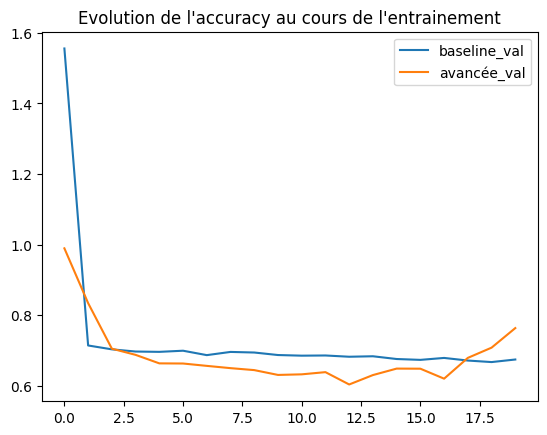

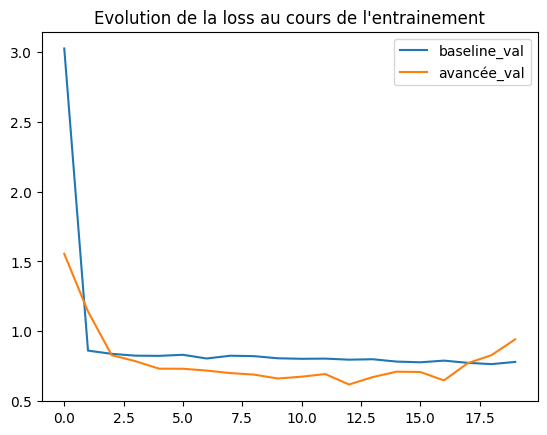

In [33]:
pd.DataFrame(acc, columns= [x for x in acc if "val" in x]).plot(title="Evolution de l'accuracy au cours de l'entrainement") 
pd.DataFrame(loss, columns= [x for x in acc if "val" in x]).plot(title="Evolution de la loss au cours de l'entrainement")

## Etude 2 : Classement d'images sur les données CIFAR-10

In [34]:
from keras.datasets import cifar10 
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step


c:\#Cours\BUT 3\Machine Learning\.venv\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


In [ ]:
y_train[]

array([9], dtype=uint8)